# Inventory Optimization for Retail Chain

## 1) Data Introduction:

File descriptions:
- train.csv - Training data.
- test.csv - Test data.
- sample_submission.csv - a sample submission file in the correct format.

Data fields:

|Column Name|Description|
|-----------|-----------|
|date|Date of the sale data. There are no holiday effects or store closures.|
|store|Store ID|
|item|Item ID|
|sales|Number of items sold at a particular store on a particular date.|

## 2) Downloading and Importing Libraries:

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Check libraries and Python version.
print("Python version:", sys.version)

Python version: 3.11.13 (main, Jun  3 2025, 18:38:25) [Clang 17.0.0 (clang-1700.0.13.3)]


## 3) Loading Dataset:

In [3]:
df = pd.read_csv('../data/demand-forecasting-kernels-only/train.csv')
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 4) Data Preprocesing and Exploratory Data Analysis:

### 4.1) Overview the dataset:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


The dataset contains 4 columns with 913,000 non-null values and 4 features. However, the data type of the `date` column is incorrect and needs to be redefined.

In [5]:
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


The type of `date` column is correct.

**Let’s examine the values of each feature in the dataset, including the count, mean, standard deviation, minimum, 25th percentile, median (50%), 75th percentile, and maximum:**

In [7]:
df.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


The values in each column are appropriate in context.

**Let's examine the number of records by store ID:**

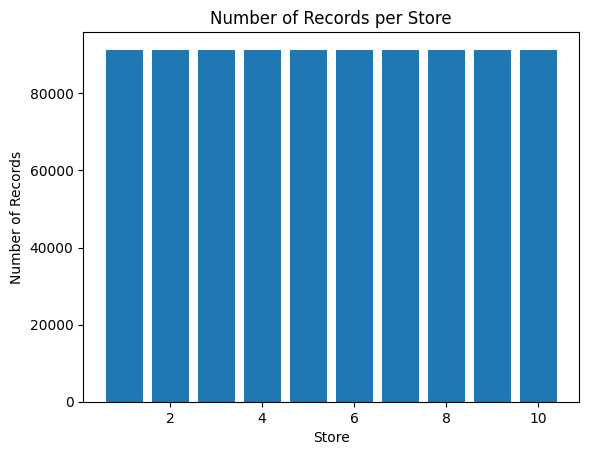

In [8]:
x = df['store'].unique()
y = df['store'].value_counts().values
plt.bar(x, y)
plt.xlabel('Store')
plt.ylabel('Number of Records')
plt.title('Number of Records per Store')
plt.show()

All stores have an equal number of records.

### 4.2) Data Preprocessing:

**Let's extract the `date` column:**

In [9]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df.head()

,date,store,item,sales,year,month,day
0,2013-01-01,1,1,13,2013,1,1
1,2013-01-02,1,1,11,2013,1,2
2,2013-01-03,1,1,14,2013,1,3
3,2013-01-04,1,1,13,2013,1,4
4,2013-01-05,1,1,10,2013,1,5


**Let's add the `day_of_week` column:**

`day_of_week`: 0 - 6 (Monday - Sunday).

`day_of_week_name`: Monday - Sunday.

In [10]:
df['day_of_week'] = df['date'].dt.dayofweek
df.head()

,date,store,item,sales,year,month,day,day_of_week
0,2013-01-01,1,1,13,2013,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2
2,2013-01-03,1,1,14,2013,1,3,3
3,2013-01-04,1,1,13,2013,1,4,4
4,2013-01-05,1,1,10,2013,1,5,5


In [11]:
df['day_of_week_name'] = df['date'].dt.day_name()
df.head()

,date,store,item,sales,year,month,day,day_of_week,day_of_week_name
0,2013-01-01,1,1,13,2013,1,1,1,Tuesday
1,2013-01-02,1,1,11,2013,1,2,2,Wednesday
2,2013-01-03,1,1,14,2013,1,3,3,Thursday
3,2013-01-04,1,1,13,2013,1,4,4,Friday
4,2013-01-05,1,1,10,2013,1,5,5,Saturday


**Let's add the `is_weekend` column:**

`is_weekend`: 1 if `day_of_week` >= 5 (Saturday or Sunday), otherwise 0.

In [12]:
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
df.head()

,date,store,item,sales,year,month,day,day_of_week,day_of_week_name,is_weekend
0,2013-01-01,1,1,13,2013,1,1,1,Tuesday,0
1,2013-01-02,1,1,11,2013,1,2,2,Wednesday,0
2,2013-01-03,1,1,14,2013,1,3,3,Thursday,0
3,2013-01-04,1,1,13,2013,1,4,4,Friday,0
4,2013-01-05,1,1,10,2013,1,5,5,Saturday,1


**Let's add the `quarter` column:**

In [13]:
df['quarter'] = df['date'].dt.quarter
df.head()

,date,store,item,sales,year,month,day,day_of_week,day_of_week_name,is_weekend,quarter
0,2013-01-01,1,1,13,2013,1,1,1,Tuesday,0,1
1,2013-01-02,1,1,11,2013,1,2,2,Wednesday,0,1
2,2013-01-03,1,1,14,2013,1,3,3,Thursday,0,1
3,2013-01-04,1,1,13,2013,1,4,4,Friday,0,1
4,2013-01-05,1,1,10,2013,1,5,5,Saturday,1,1


### 4.3) Data Analysis:

#### 1) Has overall sales across the entire chain grown over time?

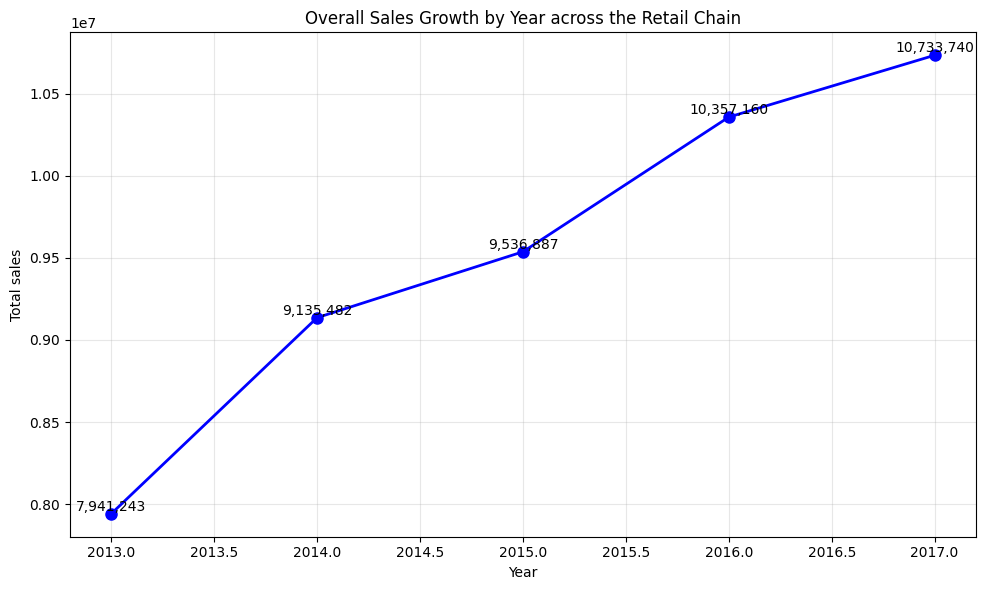

In [14]:
x = df['year'].unique()
y = df['sales'].groupby(df['year']).sum()
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, marker='o', markersize=8)
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.text(xi, yi, f'{yi:,.0f}', ha='center', va='bottom', fontsize=10)
plt.xlabel('Year')
plt.ylabel('Total sales')
plt.title('Overall Sales Growth by Year across the Retail Chain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The chart shows us the sales trend across 4 years:
- In 2013, total sales across all stores reached 7,941,243 items sold.
- In 2014, sales grew significantly, with total sales increasing 1.15 times compared to 2013. This indicates that the stores were expanding very rapidly.
- In 2015, growth slowed down, but total sales across all stores still increased slightly — rising 1.04 times compared to 2014 (and 1.20 times compared to 2013).
- From 2015 to 2017, total sales increased rapidly each year.

**Conclusion:** From 2013 to 2017, sales increased significantly every year. This shows strong overall growth across the entire period.

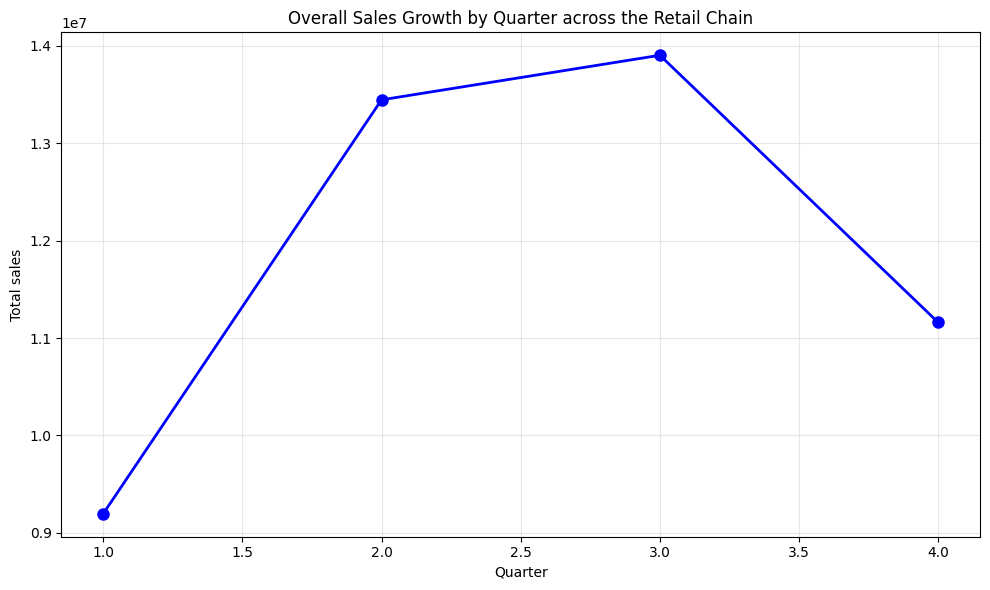

In [15]:
x = df['quarter'].unique()
y = df['sales'].groupby(df['quarter']).sum()
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, marker='o', markersize=8)
plt.xlabel('Quarter')
plt.ylabel('Total sales')
plt.title('Overall Sales Growth by Quarter across the Retail Chain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The chart show the sales trend across 4 quarter:
- Sales increased significantly from Q1 to Q3, rising from approximately 9,000,000 items sold in Q1 to around 14,000,000 items in Q3.
- In Q4, sales declined sharply following the summer peak, likely due to reduced consumer demand during the winter season compared to the high-demand summer period

**Conclusion:** The chart clearly shows that sales peak in Q3. Therefore, the retail chain should plan to import and stock significantly larger quantities of goods in preparation for Q3 (and to some extent Q2) than in the other quarters. This proactive approach will help maximize performance, meet peak demand, and boost overall revenue for the entire chain.

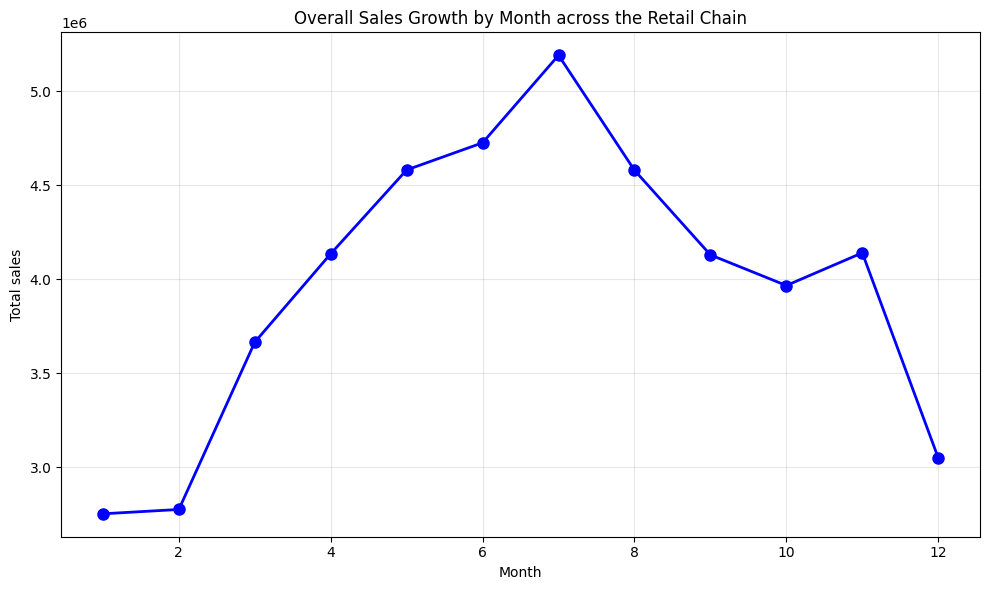

In [16]:
x = df['month'].unique()
y = df['sales'].groupby(df['month']).sum()
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, marker='o', markersize=8)
plt.xlabel('Month')
plt.ylabel('Total sales')
plt.title('Overall Sales Growth by Month across the Retail Chain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The chart shows the sales trend across 12 months:
- Total sales increased steadily from January to July, peaking in July at over 5,000,000 items sold.
- After July, sales decreased steadily over the following months. This could be due to store disruptions or reduced consumer demand. However, the decline did not last long - it ended in October, followed by an increase in November.
- In December, total sales declined significantly again.

**Conclusion:** Total sales showed unusual fluctuations throughout the year. Consumer demand tended to decrease in the last months of the year.

**Summary:** Although the line charts below use different time scales (year vs. monthly/quarterly), together they provide clear insights into the performance and growth of the entire retail chain over time:
- Total sales across all stores grew steadily year-over-year, rising from 7,941,243 items in 2013 to 10,733,740 items in 2017 — a strong and consistent upward trend.
- Monthly sales showed significant fluctuations throughout the year, with the highest volumes consistently occurring in Q3 (typically peaking in July). As a result, the chain should increase procurement and import larger quantities of goods in June to adequately prepare for this seasonal peak and avoid stockouts.

#### 2) Does revenue increase on weekends?

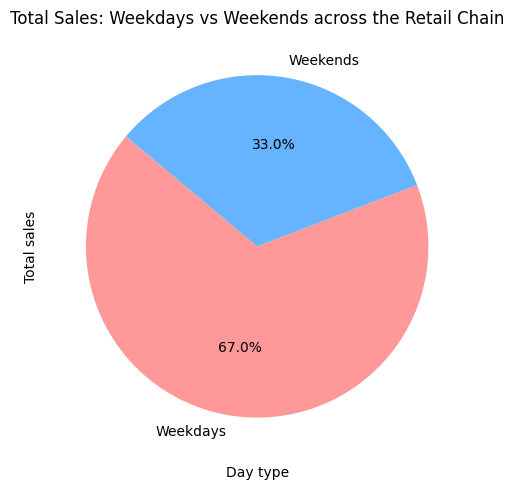

In [17]:
week_size = []
for i in df['is_weekend'].unique():
    week_size.append(df['sales'][df['is_weekend'] == i].sum())
plt.figure(figsize=(8, 5))
plt.pie(week_size, labels=['Weekdays', 'Weekends'], colors=['#ff9999', '#66b3ff'], autopct='%1.1f%%', startangle=140)
plt.xlabel('Day type')
plt.ylabel('Total sales')
plt.title('Total Sales: Weekdays vs Weekends across the Retail Chain')
plt.tight_layout()
plt.show()

The pie chart illustrates the proportion of total sales occurring on weekdays versus weekends:
- 67% on weekdays.
- 33% on weekends.

However, since there are only two weekend days compared to five weekdays, the total weekly sales volume from weekdays is likely higher overall. To better understand this dynamic, we now turn to a more detailed analysis of the daily sales distribution

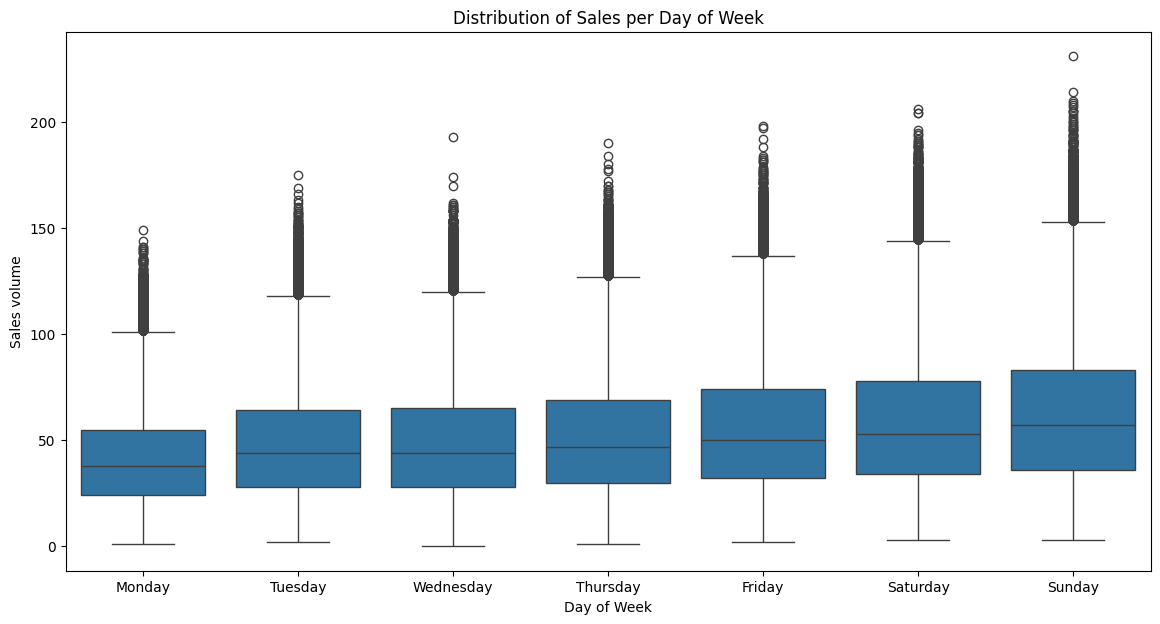

In [18]:
plt.figure(figsize=(14, 7))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='day_of_week_name', y='sales', data=df, order=day_order)
plt.title('Distribution of Sales per Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Sales volume')
plt.show()

The pie chart above shows that overall sales volume is heavily concentrated on weekdays. However, when we examine the daily sales distribution in more detail, the situation appears quite different — and in some ways contradictory to the pie chart summary. By looking at the boxplot, several clear differences between weekdays and weekends emerge:
- Weekdays: Sales show a gradual increase from the start of the week (Monday) through to Friday. The median daily sales rise from around 30 items on Monday to approximately 40 items by Friday.
- Weekends (Saturday and Sunday): Sales continue to rise further. Notably, there is an outlier on Sunday exceeding 200 items sold in a single day. This indicates that weekends (particularly Sunday) can generate significantly stronger performance on peak days.
- Implication: Although weekdays account for the majority of total sales volume (due to more days), individual weekend days often show higher per-day potential and greater variability (including extreme high-sales days). To avoid stockouts during these high-demand weekend periods, the chain should increase inventory allocation and procurement specifically for Saturday and Sunday. In contrast, weekday demand is more stable and moderate — so there is less need to overstock on those days. Excess inventory from weekends could even be carried over to support weekday sales.

**Conclusion:** Weekend days exhibit higher per-day sales potential and greater upside compared to weekdays. To fully capitalize on this demand and prevent lost sales due to insufficient stock, the retail chain should focus inventory buildup and supply planning on weekends. This targeted approach will help meet peak customer demand more effectively and drive higher overall revenue for the entire chain.

#### 3) Which store sells the best? Do the stores follow the same pattern of price increases and decreases?

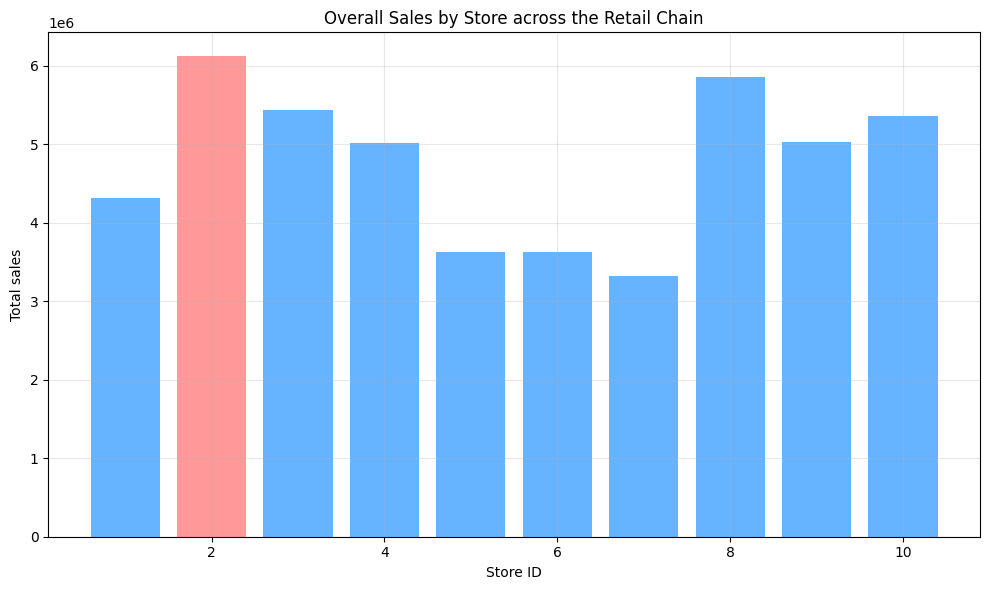

In [19]:
x = df['store'].unique()
y = df['sales'].groupby(df['store']).sum()
colors = ['#ff9999' if value == max(y) else '#66b3ff' for value in y] # Pop out the max value color
plt.figure(figsize=(10, 6))
plt.bar(x, y, color=colors)
plt.xlabel('Store ID')
plt.ylabel('Total sales')
plt.title('Overall Sales by Store across the Retail Chain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

From the observations, the chart clearly answers the question:
- Store 2 is the top-performing store (from 2013 to 2017), with over 6,000,000 items sold.
- Store 8 ranks second, with nearly 6,000,000 items sold.
- Store 7 has the lowest sales compared to the other stores.

**Conclusion:** Store 2 was the best-performing store from 2013 to 2017.

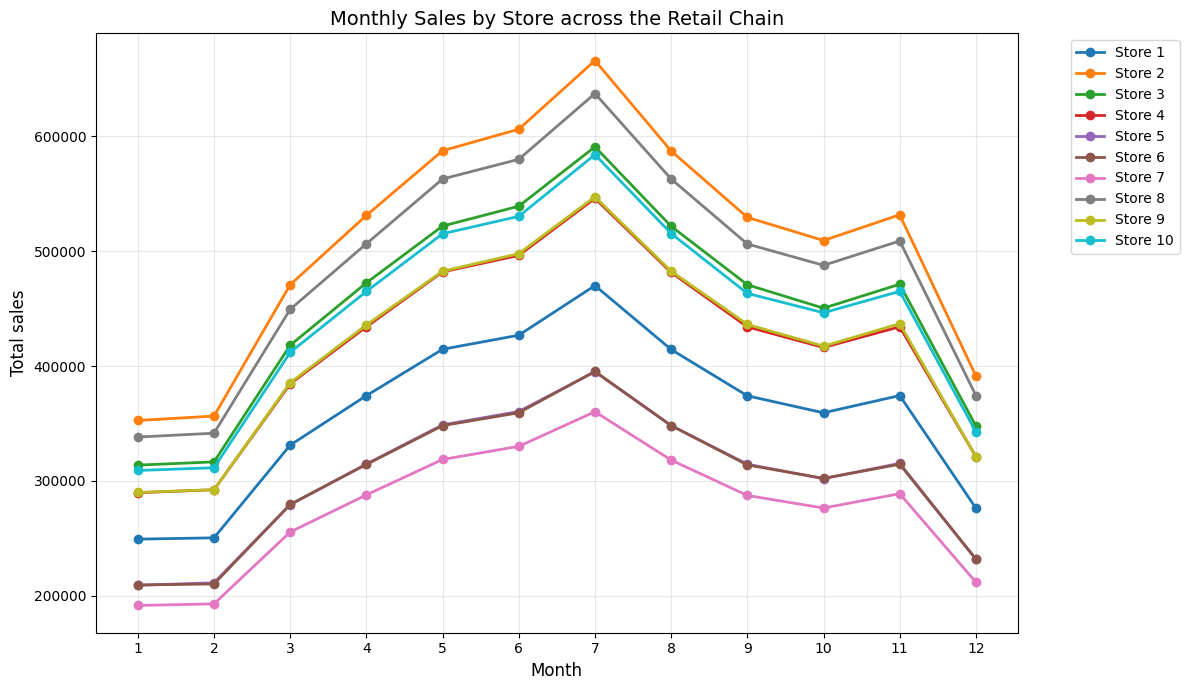

In [20]:
plt.figure(figsize=(12, 7))
stores = sorted(df['store'].unique())
# Each store line plot
for store in stores:
    store_data = df[df['store'] == store]
    monthly_sales = store_data.groupby('month')['sales'].sum()
    plt.plot(monthly_sales.index, monthly_sales.values, marker='o', label=f'Store {store}', linewidth=2)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Total sales', fontsize=12)
plt.title('Monthly Sales by Store across the Retail Chain', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

The chart shows the monthly sales patterns across all stores as follows:
- All lines follow the same overall pattern.
- Sales increased from January to July, then decreased steadily from July through October. After a slight increase in November, sales declined again in December.
- In overview, this reflects the typical monthly sales trend observed across all stores.

**Conclusion:** All lines move in parallel, indicating that every store is affected in a similar way — most likely due to broader market fluctuations or seasonal demand patterns.

#### 4) Which product is the best-selling?

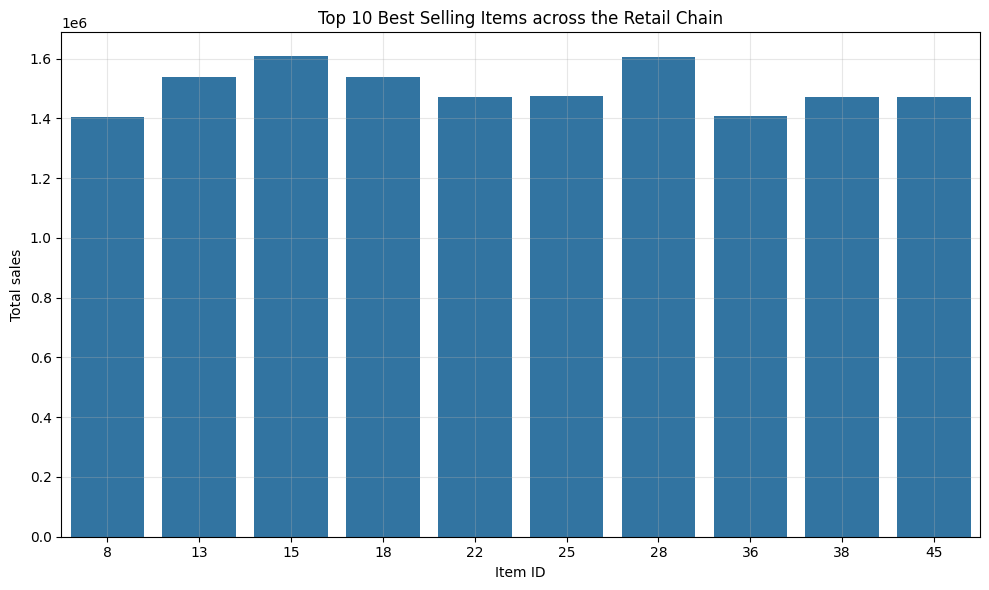

In [ ]:
# top 10 best selling items
item_sales = df.groupby("item")["sales"].sum().reset_index()
top_items = item_sales.sort_values(by="sales", ascending=False).head(10)
# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x="item", y="sales", data=top_items)
plt.xlabel('Item ID')
plt.ylabel('Total sales')
plt.title('Top 10 Best Selling Items across the Retail Chain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

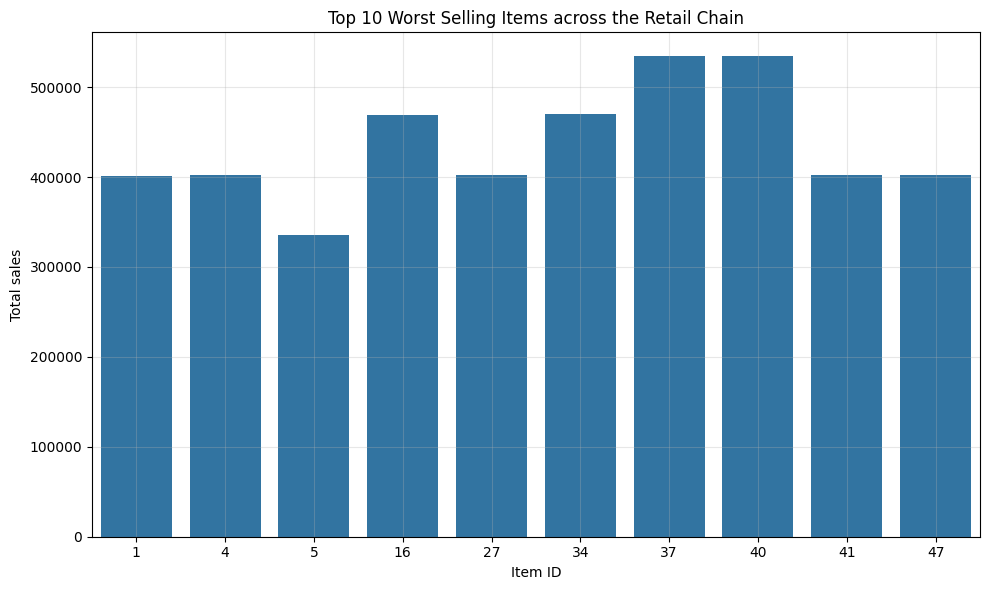

In [ ]:
# top 10 worst selling items
item_sales = df.groupby("item")["sales"].sum().reset_index()
top_items = item_sales.sort_values(by="sales", ascending=True).head(10)
# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x="item", y="sales", data=top_items)
plt.xlabel('Item ID')
plt.ylabel('Total sales')
plt.title('Top 10 Worst Selling Items across the Retail Chain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The charts show the best- and worst-performing items across the entire retail chain:
- The best-selling items are those with IDs 15 and 28, each with nearly 16,000,000 items sold. The chain should consider increasing import quantities for these high-performing items to maximize revenue.
- The worst-selling item is the one with ID 5, with only nearly 350,000 items sold — significantly lower than IDs 15 and 28. Based on this observation, the chain could reduce the stock volume for this item to cut costs and reallocate resources toward higher-performing products.

**Conclusion:** Sales performance varies greatly across item IDs. Some items achieve very high sales volumes, while others show consistently low performance across all stores in the chain. This analysis provides a clear warning. The chain should significantly reduce stock levels for the worst-performing items (e.g., ID 5) and reallocate those resources to higher-performing goods (e.g., IDs 15 and 28) in order to optimize inventory efficiency, reduce waste, and improve overall profitability.

#### 5) Is the sales distribution normal (bell-shaped) or skewed?

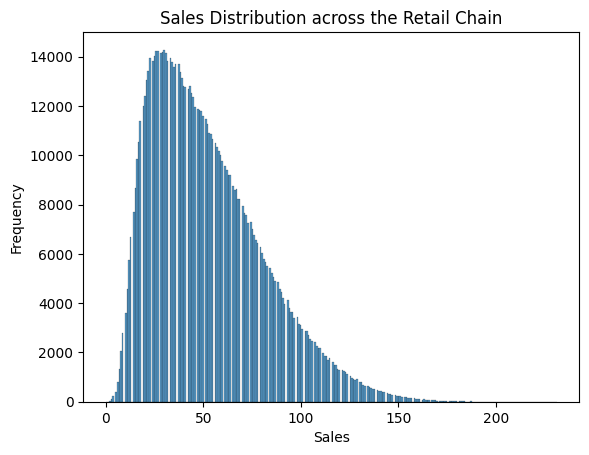

In [23]:
sns.histplot(df['sales'])
plt.title('Sales Distribution across the Retail Chain')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

The histogram illustrates the distribution of daily sales across the entire retail chain. Key observations include:
- The distribution is slightly left-skewed in appearance, but upon closer inspection, it is right-skewed (positively skewed).
- The majority of days have relatively low to moderate sales, with the highest frequency concentrated in the range of 30–50 items sold per day.
- Days with exceptionally high sales (above 100 items) are rare and appear as a long right tail. These outliers likely correspond to special events such as Black Friday, major holidays, flash sales, or other promotional peaks. 
- After the mode (around 30–50 items), the frequency decreases steadily, but the tail extends quite far — reaching up to approximately 200 items on the most extreme days.

**Conclusion:** The daily sales volume follows a right-skewed (positively skewed) distribution. On most days, the chain sells a relatively modest number of items (typically 30–50 per day), reflecting normal operating conditions. Extremely high-sales days (>100 items) are infrequent and represent significant but uncommon spikes, likely driven by seasonal promotions, holidays, or large-scale marketing campaigns.

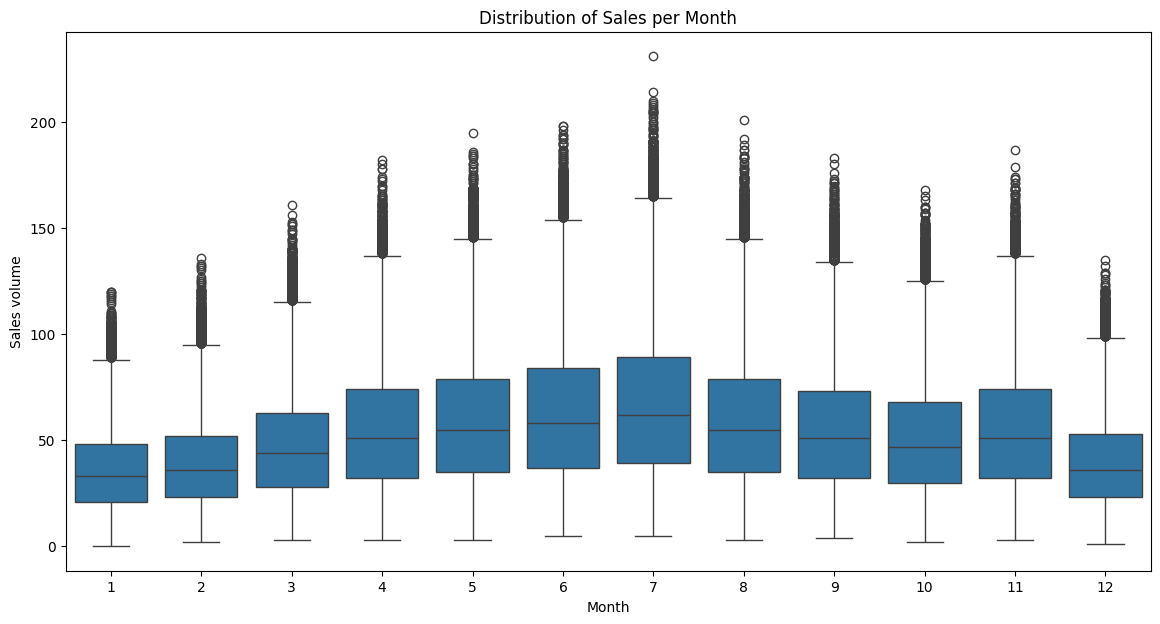

In [24]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='month', y='sales', data=df)
plt.title('Distribution of Sales per Month')
plt.xlabel('Month')
plt.ylabel('Sales volume')
plt.show()

The boxplot illustrates the distribution of sales per month across the entire chain. Key observation includes:
- The median sales show a clear upward trend from the beginning of the year, peaking in the summer (July), then gradually declining toward the end of the year, with a slight recovery in November. This pattern strongly suggests that product demand is heavily influenced by seasonal weather or summer-related activities.
- The high-demand months (particularly June, July, and August) exhibit significantly larger interquartile ranges (IQR) compared to other months. This indicates much greater variability and fluctuation in customer demand during peak season, requiring more flexible and responsive inventory planning than in the more stable low-season months (such as January and December).
- Numerous upper outliers appear in every month, highlighting that sudden sales spikes are common across the year — likely driven by short-term promotions, flash sales, or other temporary demand surges.

**Conclusion:** The boxplot clearly reveals the strong seasonality of the retail chain. Sales reach their annual peak in July, but this high season (June–August) is also accompanied by significantly higher risk and variability. In addition, the frequent presence of upper outliers throughout the year — combined with the noticeable November uptick — demonstrates that demand is strongly influenced by promotional campaigns and year-end events.